In [53]:
import numpy as np
from lorenz63 import lorenz
from matplotlib import pyplot as plt

## Mathematical Description of `KoopmanEstimator`

This implementation builds a finite-dimensional approximation of the Koopman operator using EDMD (Extended Dynamic Mode Decomposition).

Given state snapshots $x_k \in \mathbb{R}^n$ and next-step snapshots $y_k \in \mathbb{R}^n$, it learns linear dynamics in a lifted observable space.

### 1. Observable (lifting) map

Choose a dictionary of observables $\psi: \mathbb{R}^n \to \mathbb{R}^m$ and define

$$
\psi(x) = [\psi_1(x), \ldots, \psi_m(x)]^\top.
$$

Supported dictionaries are:

- **Linear:** raw state (and optional bias term).
- **Polynomial:** monomials up to selected degree (plus optional state and bias).
- **RBF:** radial basis functions $\exp(-\gamma\|x-c_j\|^2)$ with learned centers $c_j$ (plus optional state and bias).

### 2. Lifted snapshot matrices

Form lifted data matrices

$$
\Psi_X =
\begin{bmatrix}
\psi(x_1)^\top \\
\vdots \\
\psi(x_N)^\top
\end{bmatrix},
\qquad
\Psi_Y =
\begin{bmatrix}
\psi(y_1)^\top \\
\vdots \\
\psi(y_N)^\top
\end{bmatrix}.
$$

If explicit $Y$ is not provided, the code uses consecutive pairs from one trajectory: $(x_k, y_k) = (X_k, X_{k+1})$.

### 3. Koopman operator fit (least squares / ridge)

It solves

$$
K = \arg\min_K \|\Psi_X K - \Psi_Y\|_F^2,
$$

or with Tikhonov regularization $\lambda = \texttt{reg}$:

$$
K = \arg\min_K \|\Psi_X K - \Psi_Y\|_F^2 + \lambda \|K\|_F^2.
$$

### 4. Decoder back to state space

A linear decoder is learned as

$$
B = \arg\min_B \|\Psi_X B - X\|_F^2,
$$

so a state estimate from observables is $\hat{x} = \psi(x) B$.

### 5. Prediction

Given initial state $x_0$, prediction proceeds in lifted space:

$$
\psi_{k+1} = \psi_k K,
\qquad
\hat{x}_{k+1} = \psi_{k+1} B.
$$

For $s$-step prediction:

$$
\hat{x}_{k+s} = \psi(x_k) K^s B.
$$

### 6. Reconstruction

Reconstruction returns the trajectory

$$
[x_0, \hat{x}_1, \hat{x}_2, \ldots, \hat{x}_T],
$$

using the same prediction recursion.

### 7. Spectral quantities

After fitting $K$, eigenpairs satisfy

$$
K v_i = \lambda_i v_i.
$$

The code stores:

- **Discrete-time eigenvalues:** $\lambda_i$.
- **Continuous-time eigenvalues:**

$$
\mu_i = \frac{\log(\lambda_i)}{\Delta t},
$$

with user-provided timestep $\Delta t$.

In [69]:
times = np.arange(0, 5, 0.001)
xstate, ystate, zstate = 1, 1, 1
rho, beta, sigma = 10, 8.0/3.0, 10.0   #spiral into one of two stable equilibria depending on initial conditions

out = lorenz(time_series=times, init_state=[xstate, ystate, zstate], parameters=[rho, beta, sigma])

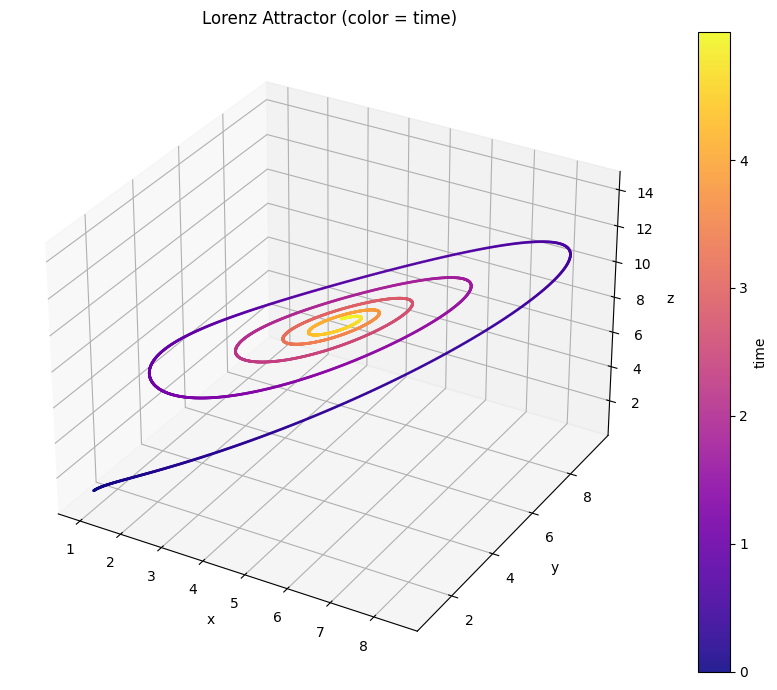

In [70]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')


sc = ax.scatter(
    out[:, 0], out[:, 1], out[:, 2],
    c=times, cmap='plasma', s=1, alpha=0.9
)

ax.set_title("Lorenz Attractor (color = time)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
fig.colorbar(sc, ax=ax, label="time")

plt.tight_layout()
plt.show()

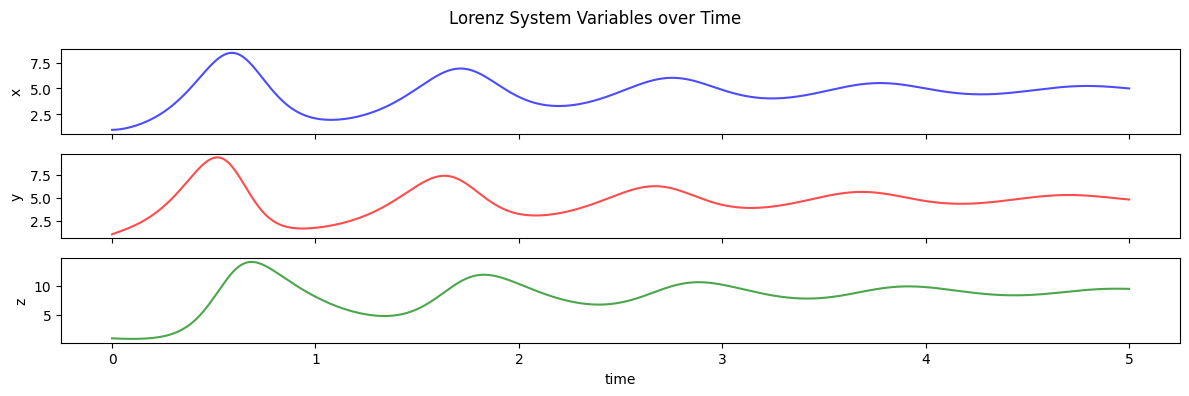

In [71]:
fig, axes = plt.subplots(3, 1, figsize=(12, 4), sharex=True)

axes[0].plot(times, out[:, 0], color='blue', alpha=0.7)
axes[0].set_ylabel("x")

axes[1].plot(times, out[:, 1], color='red', alpha=0.7)
axes[1].set_ylabel("y")

axes[2].plot(times, out[:, 2], color='green', alpha=0.7)
axes[2].set_ylabel("z")
axes[2].set_xlabel("time")

fig.suptitle("Lorenz System Variables over Time")
plt.tight_layout()
plt.show()

In [72]:
# Split the z coordinate into train and test sets
train_size = int(0.8 * len(out))
z_train = out[1000:train_size, 2]
z_test = out[train_size:, 2]

t_train = times[1000:train_size]
t_test = times[train_size:]

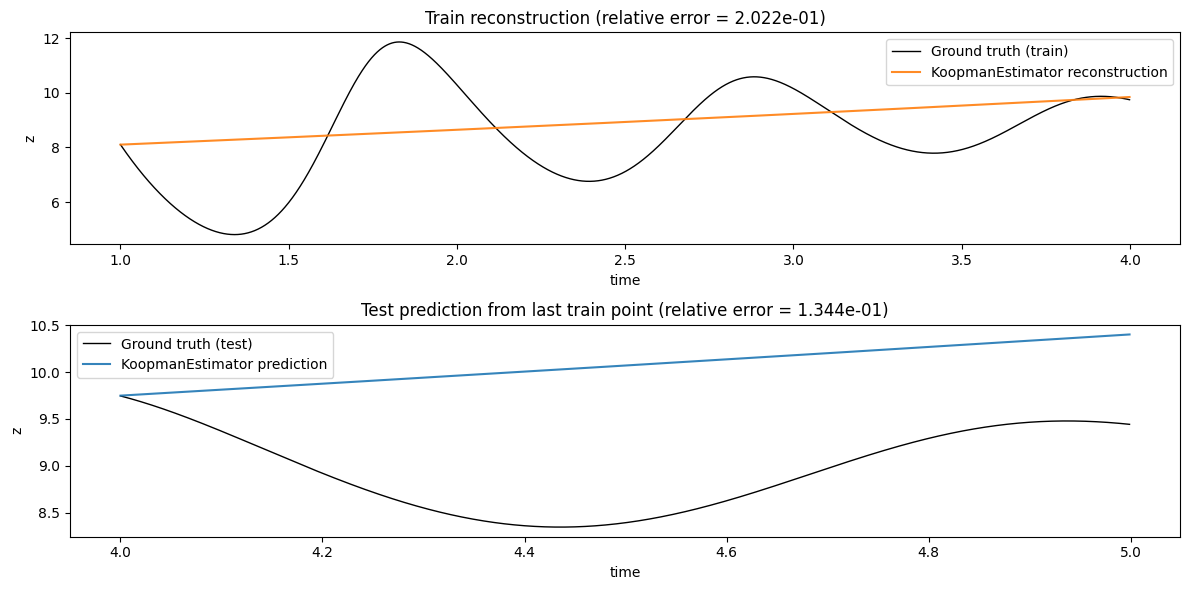

Estimated Koopman scalar K = 1.000065


In [73]:
# Linear Koopman model on z(t) using KoopmanEstimator
from koopman import KoopmanEstimator


lin_model = KoopmanEstimator(
    observable_type="polynomial",
    degree=1,
    include_bias=False,
    include_state=True,
    dt=times[1] - times[0],
    reg=1e-8,
    random_state=0,
)

# Fit on training trajectory (n_samples x n_states)
lin_model.fit(z_train.reshape(-1, 1))

# Training reconstruction (rollout from first training point)
z_train_rec = lin_model.reconstruct(np.array([z_train[0]]), n_steps=len(z_train) - 1)[:, 0]

# Test prediction (rollout from last training point)
z_test_pred = lin_model.predict(np.array([z_train[-1]]), steps=len(z_test))[0, :, 0]

# Relative errors vs ground truth
train_rel_err = np.linalg.norm(z_train_rec - z_train) / np.linalg.norm(z_train)
test_rel_err = np.linalg.norm(z_test_pred - z_test) / np.linalg.norm(z_test)

# Plots against ground truth
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

axes[0].plot(t_train, z_train, label="Ground truth (train)", color="black", linewidth=1)
axes[0].plot(t_train, z_train_rec, label="KoopmanEstimator reconstruction", color="tab:orange", alpha=0.9)
axes[0].set_title(f"Train reconstruction (relative error = {train_rel_err:.3e})")
axes[0].set_xlabel("time")
axes[0].set_ylabel("z")
axes[0].legend()

axes[1].plot(t_test, z_test, label="Ground truth (test)", color="black", linewidth=1)
axes[1].plot(t_test, z_test_pred, label="KoopmanEstimator prediction", color="tab:blue", alpha=0.9)
axes[1].set_title(f"Test prediction from last train point (relative error = {test_rel_err:.3e})")
axes[1].set_xlabel("time")
axes[1].set_ylabel("z")
axes[1].legend()

plt.tight_layout()
plt.show()

K = np.real_if_close(lin_model.eigenvalues_discrete_[0]).item()
print(f"Estimated Koopman scalar K = {K:.6f}")

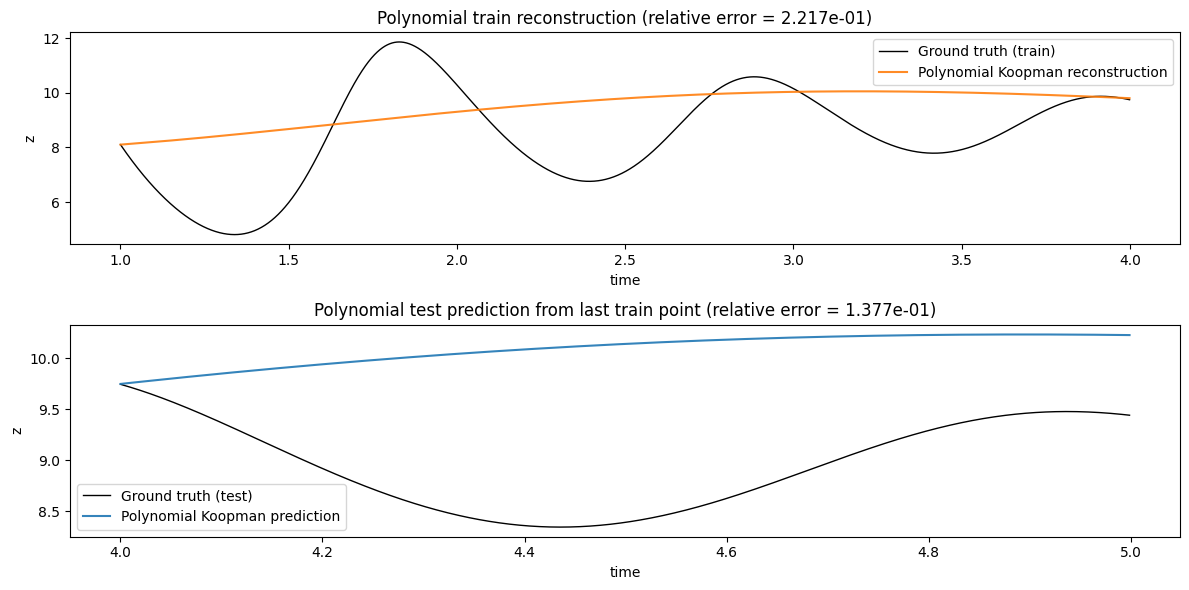

Polynomial Koopman observables: 11
Largest |lambda_d|: 1.000000
First 5 discrete eigenvalues: [0.51715871+0.23681383j 0.51715871-0.23681383j 0.76419458+0.j
 0.99974727+0.00118941j 0.99974727-0.00118941j]
First 5 continuous eigenvalues: [-5.64225657e+02+429.41507804j -5.64225657e+02-429.41507804j
 -2.68932838e+02  +0.j         -2.52054910e-01  +1.18971371j
 -2.52054910e-01  -1.18971371j]


In [74]:
# Polynomial Koopman model on z(t) using KoopmanEstimator from koopman.py
from koopman import KoopmanEstimator


# EDMD with polynomial observables
poly_model = KoopmanEstimator(
    observable_type="polynomial",
    degree=10,
    include_bias=True,
    include_state=True,
    dt=times[1] - times[0],
    reg=1e-8,
    random_state=0,
)

# Fit on training trajectory (as column vector: n_samples x n_states)
poly_model.fit(z_train.reshape(-1, 1))

# Training reconstruction (rollout from first training point)
z_train_rec = poly_model.reconstruct(np.array([z_train[0]]), n_steps=len(z_train) - 1)[:, 0]

# Test prediction (rollout from last training point)
z_test_pred = poly_model.predict(np.array([z_train[-1]]), steps=len(z_test))[0, :, 0]

# Relative errors vs ground truth
train_rel_err = np.linalg.norm(z_train_rec - z_train) / np.linalg.norm(z_train)
test_rel_err = np.linalg.norm(z_test_pred - z_test) / np.linalg.norm(z_test)

# Plots against ground truth
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

axes[0].plot(t_train, z_train, label="Ground truth (train)", color="black", linewidth=1)
axes[0].plot(t_train, z_train_rec, label="Polynomial Koopman reconstruction", color="tab:orange", alpha=0.9)
axes[0].set_title(f"Polynomial train reconstruction (relative error = {train_rel_err:.3e})")
axes[0].set_xlabel("time")
axes[0].set_ylabel("z")
axes[0].legend()

axes[1].plot(t_test, z_test, label="Ground truth (test)", color="black", linewidth=1)
axes[1].plot(t_test, z_test_pred, label="Polynomial Koopman prediction", color="tab:blue", alpha=0.9)
axes[1].set_title(f"Polynomial test prediction from last train point (relative error = {test_rel_err:.3e})")
axes[1].set_xlabel("time")
axes[1].set_ylabel("z")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Polynomial Koopman observables: {poly_model.n_observables_}")
print(f"Largest |lambda_d|: {np.max(np.abs(poly_model.eigenvalues_discrete_)):.6f}")
print("First 5 discrete eigenvalues:", poly_model.eigenvalues_discrete_[:5])
print("First 5 continuous eigenvalues:", poly_model.eigenvalues_continuous_[:5])

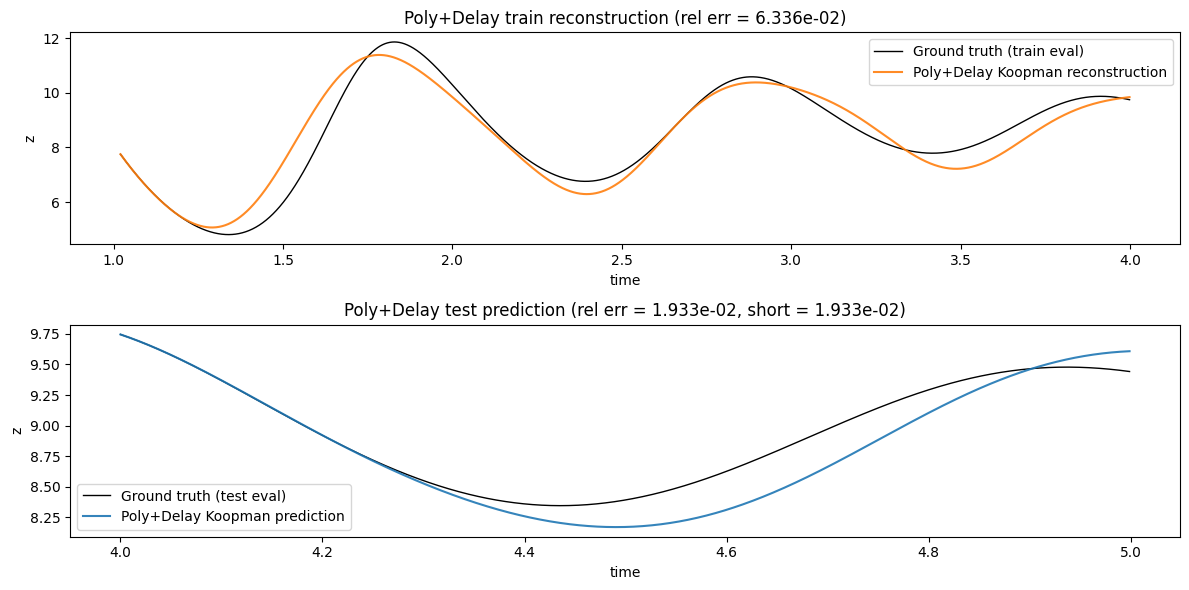

n_delays=20, degree=2
Observables: 231
Train rel err (eval horizon): 6.336e-02
Test rel err (eval horizon): 1.933e-02
Test rel err (short horizon): 1.933e-02
First 5 discrete eigenvalues: [0.45548821+0.j         0.99964396+0.01212314j 0.99964396-0.01212314j
 0.99958418+0.00564244j 0.99958418-0.00564244j]
First 5 continuous eigenvalues: [-7.86385455e+02 +0.j         -2.82571509e-01+12.12686696j
 -2.82571509e-01-12.12686696j -3.99973012e-01 +5.64473183j
 -3.99973012e-01 -5.64473183j]


In [75]:
# Time-delay embedding + polynomial Koopman on z(t)
from koopman import KoopmanEstimator

def build_delay_state(z_series, n_delays):
    z_series = np.asarray(z_series, dtype=float).ravel()
    if n_delays < 2 or n_delays > len(z_series):
        raise ValueError("n_delays must satisfy 2 <= n_delays <= len(z_series)")

    rows = []
    for t in range(n_delays - 1, len(z_series)):
        rows.append(z_series[t - n_delays + 1 : t + 1][::-1])
    return np.asarray(rows, dtype=float)


n_delays = 20
poly_degree = 2
dt = times[1] - times[0]

# Keep evaluation horizons practical for chaotic autonomous rollout
train_eval_steps = min(4000, len(z_train) - n_delays)
test_eval_steps = min(4000, len(z_test))

# Build delay-state trajectories
Z_train = build_delay_state(z_train, n_delays)
t_train_delay = t_train[n_delays - 1:]

# Normalize delay coordinates for conditioning
mu = Z_train.mean(axis=0)
sigma = Z_train.std(axis=0) + 1e-12
Z_train_s = (Z_train - mu) / sigma

# Polynomial Koopman in delay space
poly_delay_model = KoopmanEstimator(
    observable_type="polynomial",
    degree=poly_degree,
    include_bias=True,
    include_state=True,
    dt=dt,
    reg=1e-4,
    random_state=0,
    n_centers=20,
    gamma=None,
    )

poly_delay_model.fit(Z_train_s)

# Train reconstruction over a short horizon
Z_train_rec_s = poly_delay_model.predict(Z_train_s[0], steps=train_eval_steps)[0]
Z_train_rec = Z_train_rec_s * sigma + mu
z_train_true_delay = Z_train[1 : train_eval_steps + 1, 0]
z_train_rec_delay = Z_train_rec[:, 0]
t_train_eval = t_train_delay[1 : train_eval_steps + 1]

# Test autonomous prediction from last train delay-state
z_test_init = z_train[-n_delays:][::-1]
z_test_init_s = (z_test_init - mu) / sigma
Z_test_pred_s = poly_delay_model.predict(z_test_init_s, steps=test_eval_steps)[0]
Z_test_pred = Z_test_pred_s * sigma + mu
z_test_pred = Z_test_pred[:, 0]

# Errors
train_rel_err_delay = np.linalg.norm(z_train_rec_delay - z_train_true_delay) / np.linalg.norm(z_train_true_delay)
z_test_eval = z_test[:test_eval_steps]
test_rel_err_delay = np.linalg.norm(z_test_pred - z_test_eval) / np.linalg.norm(z_test_eval)
short_horizon = min(1000, test_eval_steps)
test_rel_err_short = (
    np.linalg.norm(z_test_pred[:short_horizon] - z_test_eval[:short_horizon])
    / np.linalg.norm(z_test_eval[:short_horizon])
)

# Plots
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

axes[0].plot(t_train_eval, z_train_true_delay, label="Ground truth (train eval)", color="black", linewidth=1)
axes[0].plot(t_train_eval, z_train_rec_delay, label="Poly+Delay Koopman reconstruction", color="tab:orange", alpha=0.9)
axes[0].set_title(f"Poly+Delay train reconstruction (rel err = {train_rel_err_delay:.3e})")
axes[0].set_xlabel("time")
axes[0].set_ylabel("z")
axes[0].legend()

axes[1].plot(t_test[:test_eval_steps], z_test_eval, label="Ground truth (test eval)", color="black", linewidth=1)
axes[1].plot(t_test[:test_eval_steps], z_test_pred, label="Poly+Delay Koopman prediction", color="tab:blue", alpha=0.9)
axes[1].set_title(f"Poly+Delay test prediction (rel err = {test_rel_err_delay:.3e}, short = {test_rel_err_short:.3e})")
axes[1].set_xlabel("time")
axes[1].set_ylabel("z")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"n_delays={n_delays}, degree={poly_degree}")
print(f"Observables: {poly_delay_model.n_observables_}")
print(f"Train rel err (eval horizon): {train_rel_err_delay:.3e}")
print(f"Test rel err (eval horizon): {test_rel_err_delay:.3e}")
print(f"Test rel err (short horizon): {test_rel_err_short:.3e}")
print("First 5 discrete eigenvalues:", poly_delay_model.eigenvalues_discrete_[:5])
print("First 5 continuous eigenvalues:", poly_delay_model.eigenvalues_continuous_[:5])